In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.datasets import fetch_openml
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [81]:
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data
y = mnist.target.astype(int)

In [82]:
X_train = X[:60000]
X_test = X[60000:]
y_train = y[:60000]
y_test = y[60000:]

In [83]:
X_train = X_train.values.reshape(-1, 784)
X_test = X_test.values.reshape(-1, 784)

In [84]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [85]:
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)
print("Number of classes:", len(np.unique(y_train)))

Training data shape: (60000, 784)
Test data shape: (10000, 784)
Training labels shape: (60000,)
Test labels shape: (10000,)
Number of classes: 10


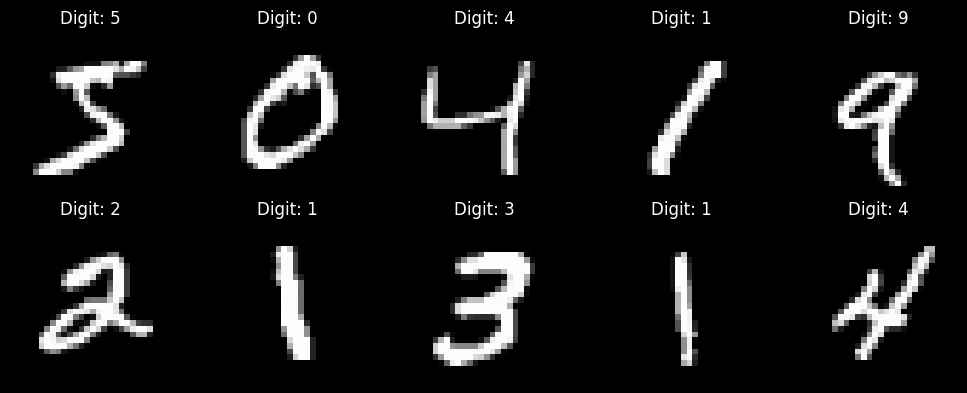

In [86]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Digit: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [87]:

# Create model
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5558


Confusion Matrix:
[[ 870    0    3    5    2    5   31    1   35   28]
 [   0 1079    2    1    0    0   10    0   38    5]
 [  79   25  266   91    5    2  269    4  271   20]
 [  32   39    6  353    2    3   51    8  409  107]
 [  19    2    5    4  168    7   63    7  210  497]
 [  71   25    1   20    3   44   40    2  586  100]
 [  12   12    3    1    1    7  895    0   26    1]
 [   0   15    2   10    5    1    5  280   39  671]
 [  13   72    3    7    3   11   12    4  648  201]
 [   5    7    3    6    1    0    1   13   18  955]]


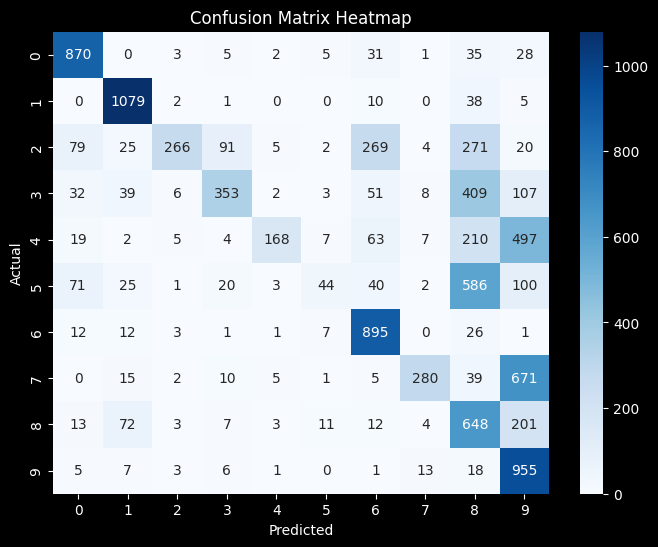

In [88]:

import matplotlib.pyplot as plt
import seaborn as sns  # optional for nicer visualization

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Optional: nicer colored heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

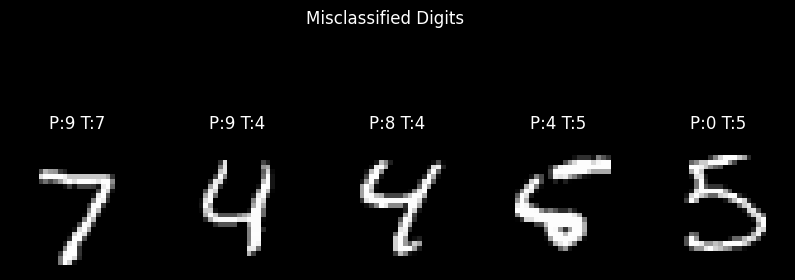

In [89]:
import numpy as np

# Convert y_test to NumPy array for proper positional indexing
y_test = y_test.to_numpy()

# Find misclassified examples
misclassified = np.where(y_test != y_pred)[0]

# Show first 5 misclassified digits
plt.figure(figsize=(10,4))
for i in range(5):
    idx = misclassified[i]
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"P:{y_pred[idx]} T:{y_test[idx]}")  # now works
    plt.axis('off')

plt.suptitle("Misclassified Digits")
plt.show()

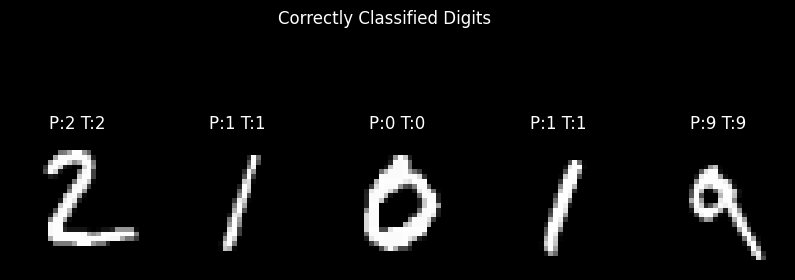

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure y_test is a NumPy array for safe indexing
y_test_array = y_test.to_numpy() if isinstance(y_test, pd.Series) else y_test

# Find correctly classified examples
correct = np.where(y_test_array == y_pred)[0]

# Show first 5 correctly classified digits
plt.figure(figsize=(10,4))
for i in range(5):
    idx = correct[i]
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"P:{y_pred[idx]} T:{y_test_array[idx]}")  # P = predicted, T = true
    plt.axis('off')

plt.suptitle("Correctly Classified Digits")
plt.show()

In [91]:

# Initialize the classifier
# GaussianNB is a good starting point for the MNIST dataset
model = GaussianNB()

# Train the model using your preprocessed training data
# This is where the 'learning' happens
model.fit(X_train, y_train)

# (Optional) Check the accuracy on your test set to see how it performs
accuracy = model.score(X_test, y_test)
print(f"Model Training Complete. Accuracy: {accuracy * 100:.2f}%")

Model Training Complete. Accuracy: 55.58%


In [92]:
from sklearn.naive_bayes import BernoulliNB
import joblib

# 1. Initialize BernoulliNB instead of GaussianNB
# binarize=0.5 automatically treats pixels as 0 or 1
improved_model = BernoulliNB(binarize=0.5)

# 2. Train the model
improved_model.fit(X_train, y_train)

# 3. Check the new accuracy
new_accuracy = improved_model.score(X_test, y_test)
print(f"Improved Accuracy: {new_accuracy * 100:.2f}%")

# 4. Save this new version
joblib.dump(improved_model, 'mnist_model.pkl')

Improved Accuracy: 84.27%


['mnist_model.pkl']